In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df=pd.read_excel(r"C:\Users\spnra\OneDrive\Documents\CodeAlpha_Data_Analytics_Dataset.xlsx")
df.head()

,Order_ID,Order_Date,City,Category,Unit_Price,Quantity,Discount_Percent,Revenue,Cost,Profit,Payment_Method
0,1,2025-01-01,Mumbai,Groceries,2381.71,3,15.0,6073.36,4319.07,1754.29,Debit Card
1,2,2025-01-02,Pune,Clothing,2566.62,5,10.0,11549.79,8560.47,2989.32,Net Banking
2,3,2025-01-03,Lucknow,Furniture,22493.97,2,0.0,44987.94,26971.13,18016.81,Credit Card
3,4,2025-01-04,Lucknow,Beauty,2762.09,1,10.0,2485.88,1635.62,850.26,Cash
4,5,2025-01-05,Bengaluru,Clothing,2221.08,4,10.0,7995.89,4498.02,3497.87,Net Banking


In [21]:
print("Shape:",df.shape)
df.info()

Shape: (300, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          300 non-null    int64         
 1   Order_Date        300 non-null    datetime64[ns]
 2   City              300 non-null    object        
 3   Category          300 non-null    object        
 4   Unit_Price        300 non-null    float64       
 5   Quantity          300 non-null    int64         
 6   Discount_Percent  296 non-null    float64       
 7   Revenue           300 non-null    float64       
 8   Cost              300 non-null    float64       
 9   Profit            300 non-null    float64       
 10  Payment_Method    296 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(2), object(3)
memory usage: 25.9+ KB


In [22]:
print("Missing Value:")
print(df.isnull().sum())

print("\,Duplicate Rows:",
df.duplicated().sum())

Missing Value:
Order_ID            0
Order_Date          0
City                0
Category            0
Unit_Price          0
Quantity            0
Discount_Percent    4
Revenue             0
Cost                0
Profit              0
Payment_Method      4
dtype: int64
\,Duplicate Rows: 0


In [23]:
df['Discount_Percent'] = df['Discount_Percent'].fillna(0)

df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')

print(df.isnull().sum())

Order_ID            0
Order_Date          0
City                0
Category            0
Unit_Price          0
Quantity            0
Discount_Percent    0
Revenue             0
Cost                0
Profit              0
Payment_Method      0
dtype: int64


In [24]:
df.describe()

,Order_ID,Order_Date,Unit_Price,Quantity,Discount_Percent,Revenue,Cost,Profit
count,300.000000,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,2025-07-01 12:33:36,11600.338600,2.980000,7.733333,29942.785700,20452.096600,9490.689100
min,1.000000,2025-01-01 00:00:00,159.010000,1.000000,0.000000,166.510000,95.490000,65.750000
25%,75.750000,2025-04-01 18:00:00,1756.277500,2.000000,0.000000,3603.435000,2474.977500,1002.017500
50%,150.500000,2025-07-01 12:00:00,4076.495000,3.000000,10.000000,11185.965000,7406.595000,3483.860000
75%,225.250000,2025-09-30 06:00:00,18586.507500,4.000000,10.000000,35220.237500,25625.012500,10896.440000
max,300.000000,2025-12-31 00:00:00,59364.850000,5.000000,20.000000,228415.290000,151557.720000,81106.650000
std,86.746758,NaN,14547.343443,1.395022,6.217536,42591.159899,29469.499266,14003.916493


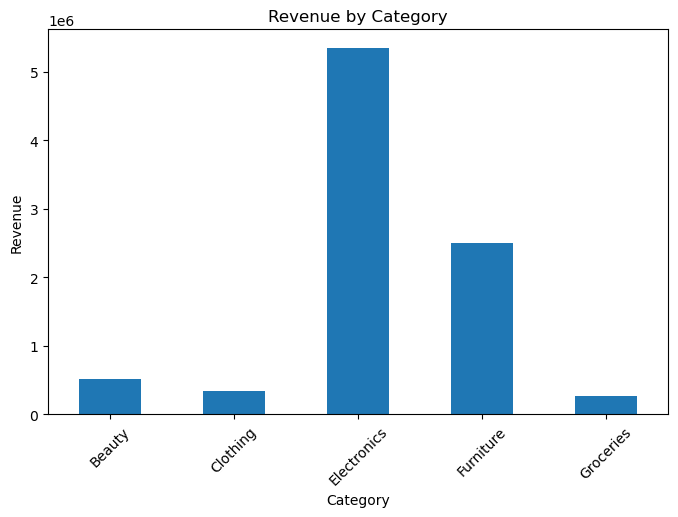

In [25]:
category_revenue = df.groupby("Category")["Revenue"].sum()

category_revenue.plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

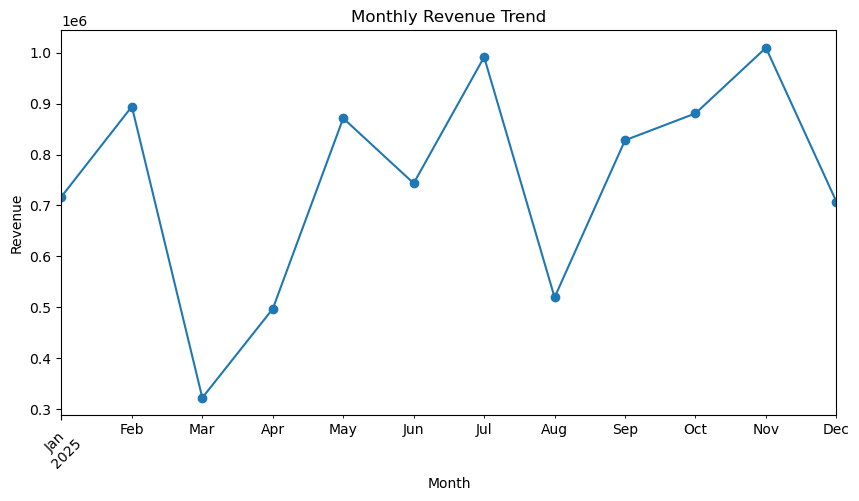

In [26]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_revenue = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_revenue.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

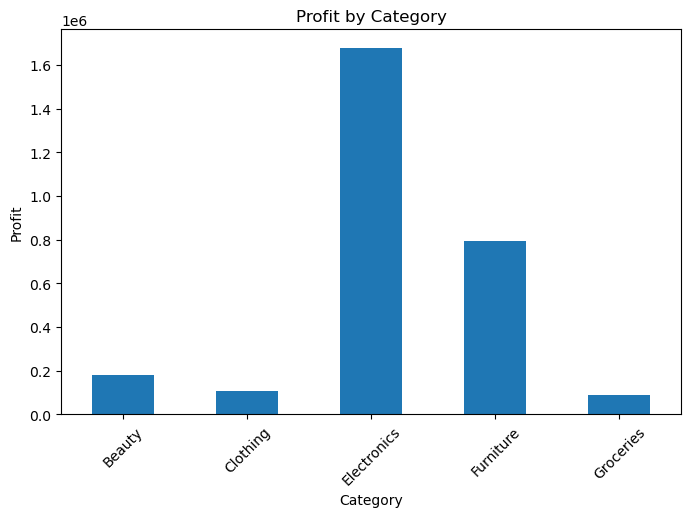

In [27]:
category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar", figsize=(8,5))
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

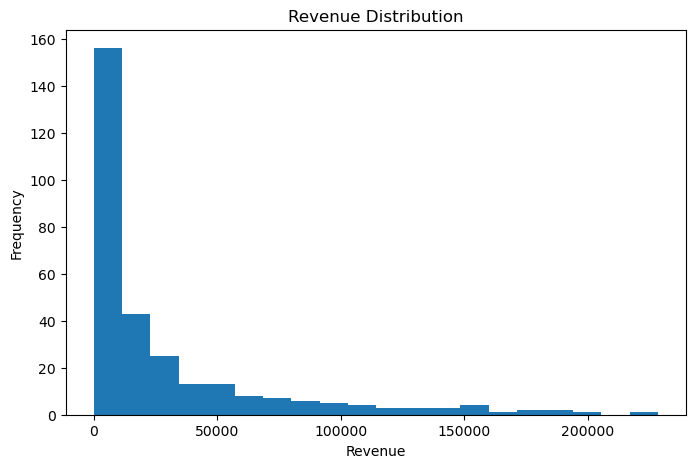

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df["Revenue"], bins=20)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

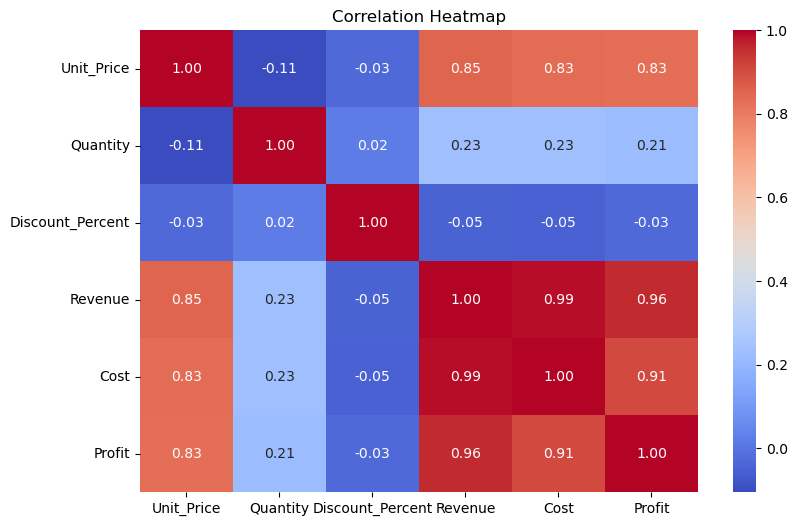

In [30]:
numeric_columns = [
    "Unit_Price",
    "Quantity",
    "Discount_Percent",
    "Revenue",
    "Cost",
    "Profit"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [34]:
print("Total Revenue:", round(df["Revenue"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))

print(
    "Highest Revenue Category:",
    df.groupby("Category")["Revenue"].sum().idxmax()
)

print(
    "Highest Profit Category:",
    df.groupby("Category")["Profit"].sum().idxmax()
)

print(
    "Highest Revenue City:",
    df.groupby("City")["Revenue"].sum().idxmax()
)

Total Revenue: 8982835.71
Total Profit: 2847206.73
Highest Revenue Category: Electronics
Highest Profit Category: Electronics
Highest Revenue City: Delhi


## Conclusion

The exploratory data analysis provided useful insights into the sales dataset.
The analysis examined revenue, profit, categories, cities, and monthly sales
trends. The visualizations helped identify patterns and relationships in the
data. Overall, the analysis provides a better understanding of sales
performance and supports data-driven decision making.